# **DL LAB 10: 13th Oct, 2025**
## **Name: Soumyadeep Ganguly**
## **Reg No: 24MDT0082**

In [1]:
from tensorflow.keras.layers import SimpleRNN, Dense,LSTM, GRU, Embedding
from tensorflow.keras.datasets import imdb
from tensorflow.keras.models import Sequential
import numpy as np

vocab_size = 10000
(X_train, y_train), (X_test, y_test) = imdb.load_data(num_words=vocab_size)
print(X_train.shape, y_train.shape, X_test.shape, y_test.shape)

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
(25000,) (25000,) (25000,) (25000,)


In [3]:
reverse_index = dict([(value, key) for (key, value) in index.items()])
print(reverse_index[1])

decoded = " ".join([reverse_index.get(i-3, "#") for i in X_test[1]])
print(decoded)

the
# this film requires a lot of patience because it focuses on mood and character development the plot is very simple and many of the scenes take place on the same set in frances # the sandy dennis character apartment but the film builds to a disturbing climax br br the characters create an atmosphere # with sexual tension and psychological # it's very interesting that robert altman directed this considering the style and structure of his other films still the trademark altman audio style is evident here and there i think what really makes this film work is the brilliant performance by sandy dennis it's definitely one of her darker characters but she plays it so perfectly and convincingly that it's scary michael burns does a good job as the mute young man regular altman player michael murphy has a small part the # moody set fits the content of the story very well in short this movie is a powerful study of loneliness sexual # and desperation be patient # up the atmosphere and pay atte

In [4]:
print("Max length of a review: ", len(max((X_train+X_test), key=len)))
print("Min length of a review: ", len(min((X_train+X_test), key=len)))

Max length of a review:  2697
Min length of a review:  70


In [5]:
from tensorflow.keras.preprocessing import sequence
import numpy as np

max_words = 200

X_train = sequence.pad_sequences(X_train, maxlen=max_words)
X_test = sequence.pad_sequences(X_test, maxlen=max_words)
print(X_train[0])

X_valid, y_valid = X_train[:64], y_train[:64]
X_train, y_train = X_train[64:], y_train[64:]
print(X_train.shape)

# Convert to NumPy arrays with appropriate dtype
X_train = np.asarray(X_train).astype('int32')
y_train = np.asarray(y_train).astype('int32')
X_valid = np.asarray(X_valid).astype('int32')
y_valid = np.asarray(y_valid).astype('int32')
X_test = np.asarray(X_test).astype('int32')
y_test = np.asarray(y_test).astype('int32')


embd_len = 64

[   5   25  100   43  838  112   50  670    2    9   35  480  284    5
  150    4  172  112  167    2  336  385   39    4  172 4536 1111   17
  546   38   13  447    4  192   50   16    6  147 2025   19   14   22
    4 1920 4613  469    4   22   71   87   12   16   43  530   38   76
   15   13 1247    4   22   17  515   17   12   16  626   18    2    5
   62  386   12    8  316    8  106    5    4 2223 5244   16  480   66
 3785   33    4  130   12   16   38  619    5   25  124   51   36  135
   48   25 1415   33    6   22   12  215   28   77   52    5   14  407
   16   82    2    8    4  107  117 5952   15  256    4    2    7 3766
    5  723   36   71   43  530  476   26  400  317   46    7    4    2
 1029   13  104   88    4  381   15  297   98   32 2071   56   26  141
    6  194 7486   18    4  226   22   21  134  476   26  480    5  144
   30 5535   18   51   36   28  224   92   25  104    4  226   65   16
   38 1334   88   12   16  283    5   16 4472  113  103   32   15   16
 5345 

In [6]:
RNN_model = Sequential()
RNN_model.add(Embedding(vocab_size, embd_len, input_length = max_words))
RNN_model.add(SimpleRNN(128, activation="tanh", return_sequences=False))
RNN_model.add(Dense(1, activation='sigmoid'))

RNN_model.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

RNN_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [7]:
RNN_model.fit(
    X_train, y_train,
    epochs=8,
    batch_size=128,
    verbose=1,
    validation_data=(X_valid, y_valid)
)

Epoch 1/8
195/195 ━━━━━━━━━━━━━━━━━━━━ 53s 256ms/step - accuracy: 0.5414 - loss: 0.6877 - val_accuracy: 0.6719 - val_loss: 0.6195
Epoch 2/8
195/195 ━━━━━━━━━━━━━━━━━━━━ 78s 234ms/step - accuracy: 0.7091 - loss: 0.5688 - val_accuracy: 0.7031 - val_loss: 0.6018
Epoch 3/8
195/195 ━━━━━━━━━━━━━━━━━━━━ 50s 259ms/step - accuracy: 0.7693 - loss: 0.4747 - val_accuracy: 0.4844 - val_loss: 0.7283
Epoch 4/8
195/195 ━━━━━━━━━━━━━━━━━━━━ 48s 244ms/step - accuracy: 0.7246 - loss: 0.5447 - val_accuracy: 0.7188 - val_loss: 0.6136
Epoch 5/8
195/195 ━━━━━━━━━━━━━━━━━━━━ 47s 241ms/step - accuracy: 0.8034 - loss: 0.4347 - val_accuracy: 0.7188 - val_loss: 0.6486
Epoch 6/8
195/195 ━━━━━━━━━━━━━━━━━━━━ 48s 245ms/step - accuracy: 0.7638 - loss: 0.4776 - val_accuracy: 0.7656 - val_loss: 0.5572
Epoch 7/8
195/195 ━━━━━━━━━━━━━━━━━━━━ 49s 252ms/step - accuracy: 0.8613 - loss: 0.3348 - val_accuracy: 0.6719 - val_loss: 0.6328
Epoch 8/8
195/195 ━━━━━━━━━━━━━━━━━━━━ 46s 236ms/step - accuracy: 0.8814 - loss: 0.2949 - 

In [8]:
print(f"Simple RNN Score: {RNN_model.evaluate(X_test, y_test, verbose=0)[1]}")

Simple RNN Score: 0.7978399991989136


In [9]:
y_pred_prob = RNN_model.predict(X_test)
y_pred = (y_pred_prob > 0.5).astype(int).reshape(-1)

782/782 ━━━━━━━━━━━━━━━━━━━━ 18s 23ms/step


In [10]:
y_pred

array([0, 1, 0, ..., 0, 0, 0])

# **Question 2**

In [11]:
embd_len = 64
LSTM_model = Sequential()
LSTM_model.add(Embedding(vocab_size, embd_len, input_length=max_words))
LSTM_model.add(LSTM(128, activation="tanh", return_sequences=True))
LSTM_model.add(LSTM(64, activation="tanh", return_sequences=False))
LSTM_model.add(Dense(1, activation='sigmoid'))


LSTM_model.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

print(LSTM_model.summary())

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

None


In [13]:
batch_size = 128
LSTM_model.fit(
    X_train, y_train,
    batch_size=batch_size,
    epochs=5,
    validation_data=(X_test, y_test)
)

Epoch 1/5
195/195 ━━━━━━━━━━━━━━━━━━━━ 284s 1s/step - accuracy: 0.7025 - loss: 0.5487 - val_accuracy: 0.8534 - val_loss: 0.3479
Epoch 2/5
195/195 ━━━━━━━━━━━━━━━━━━━━ 284s 1s/step - accuracy: 0.9026 - loss: 0.2502 - val_accuracy: 0.8677 - val_loss: 0.3191
Epoch 3/5
195/195 ━━━━━━━━━━━━━━━━━━━━ 293s 2s/step - accuracy: 0.9330 - loss: 0.1872 - val_accuracy: 0.8619 - val_loss: 0.3828
Epoch 4/5
195/195 ━━━━━━━━━━━━━━━━━━━━ 316s 1s/step - accuracy: 0.9473 - loss: 0.1446 - val_accuracy: 0.8567 - val_loss: 0.4569
Epoch 5/5
195/195 ━━━━━━━━━━━━━━━━━━━━ 287s 1s/step - accuracy: 0.9647 - loss: 0.1042 - val_accuracy: 0.8558 - val_loss: 0.4221


In [14]:
loss, accuracy = LSTM_model.evaluate(X_test, y_test, verbose=0)
print(f'\nTest Accuracy: {accuracy*100:.2f}%')
print(f'Test Loss: {loss:.4f}')

y_pred_prob = LSTM_model.predict(X_test)
y_pred = (y_pred_prob > 0.5).astype(int).reshape(-1)
y_pred


Test Accuracy: 85.58%
Test Loss: 0.4221
782/782 ━━━━━━━━━━━━━━━━━━━━ 111s 141ms/step


array([0, 1, 1, ..., 0, 0, 0])


Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.89      0.86     12500
           1       0.88      0.83      0.85     12500

    accuracy                           0.86     25000
   macro avg       0.86      0.86      0.86     25000
weighted avg       0.86      0.86      0.86     25000


Confusion Matrix:


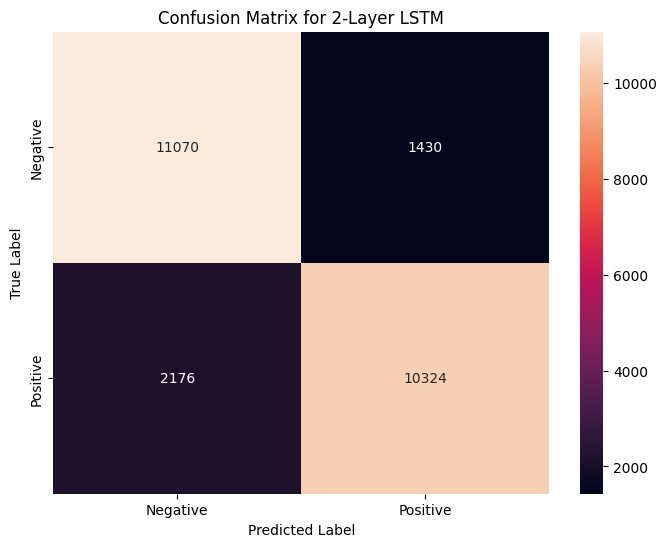

In [16]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=['Negative', 'Positive'], yticklabels=['Negative', 'Positive'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix for 2-Layer LSTM')
plt.show()
